# Step 5.1 + 6 (UPDATED): Advanced Visualization, Feature Engineering, Feature Selection & Splitting

**Extending Desai et al. (2021) — Classification of Heat Stress**  
**Stations: Colaba (43057) & Santacruz (43003)**

---

### What's in this notebook:
1. **Feature Engineering** — 10 legitimate derived features (NO target leakage)
2. **Advanced Visualizations** — Violin, Pair plots, Calendar heatmaps, t-SNE, SHAP, Correlation, Decadal shifts, Diurnal/Temporal
3. **Feature Selection** — 6 methods (Pearson, MI, ANOVA-F, RF, GB, SHAP) + rank aggregation
4. **Dataset Splitting** — Using pre-balanced CSVs from Step 4 (SMOTE-ENN primary + SMOTE comparison) + Real-world test set

### Key fix from previous version:
- **Removed target-leaking features** (Humidex, AT, Tmrt) — these were near-copies of the HI/PET formula
- **Using SMOTE-ENN** as primary balancing (best from Step 4 comparison) instead of only SMOTE
- **Added real-world test set** (2016-2025 unbalanced) for practical evaluation


In [ ]:
!pip install -q shap umap-learn imbalanced-learn scikit-learn matplotlib seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
"""
===============================================================================
  CONFIGURATION & DATA LOADING
===============================================================================
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from collections import Counter
import shap
import warnings, os, time, gc
warnings.filterwarnings('ignore')

# ============================================================
# ⚙️ CHANGE THESE FOR YOUR STATION
# ============================================================
STATION_ID = "43057"
STATION_LABEL = "43057 (Colaba)"

# For Santacruz, change to:
# STATION_ID = "43003"
# STATION_LABEL = "43003 (Santacruz)"

# Paths
BASE_DIR = "/content/drive/MyDrive/Major_project_imd"
BALANCED_DIR = os.path.join(BASE_DIR, "Class_balancing_output")
OUTPUT_DIR = os.path.join(BASE_DIR, "advanced_viz_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Input files
ORIGINAL_FILE = os.path.join(BALANCED_DIR, f'{STATION_ID}_with_HI_PET_categories.csv')

# Balanced files from Step 4
BALANCED_FILES = {
    'HI': {
        'SMOTE_ENN': os.path.join(BALANCED_DIR, f'{STATION_ID}_HI_SMOTE_ENN_balanced.csv'),
        'SMOTE':     os.path.join(BALANCED_DIR, f'{STATION_ID}_HI_SMOTE_balanced.csv'),
    },
    'PET': {
        'SMOTE_ENN': os.path.join(BALANCED_DIR, f'{STATION_ID}_PET_SMOTE_ENN_balanced.csv'),
        'SMOTE':     os.path.join(BALANCED_DIR, f'{STATION_ID}_PET_SMOTE_balanced.csv'),
    }
}

# Load original data
df = pd.read_csv(ORIGINAL_FILE, low_memory=False)
for col in ['DBT','WBT','DPT','RH','VP','FFF','TC','HI','Tmrt','PET','MN','HR','YEAR','DT']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Station: {STATION_LABEL}")
print(f"Shape: {df.shape},  Years: {df['YEAR'].min()}-{df['YEAR'].max()}")
print(f"\nHI Categories:  {dict(df['HI_Category'].value_counts().sort_index())}")
print(f"PET Categories: {dict(df['PET_Category'].value_counts().sort_index())}")
print(f"\nMissing values in key columns:")
for c in ['DBT','WBT','DPT','RH','VP','FFF','HI','PET']:
    print(f"  {c}: {df[c].isna().sum()}")


Station: 43057 (Colaba)
Shape: (59909, 44),  Years: 1969-2025

HI Categories:  {0: np.int64(34515), 1: np.int64(19946), 2: np.int64(5310), 3: np.int64(138)}
PET Categories: {0: np.int64(1729), 1: np.int64(11388), 2: np.int64(26409), 3: np.int64(16881), 4: np.int64(3502)}

Missing values in key columns:
  DBT: 0
  WBT: 0
  DPT: 0
  RH: 0
  VP: 0
  FFF: 0
  HI: 0
  PET: 0


## 1. Feature Engineering — Why These Features?

### The Problem with Previous Version:
- **HI** = f(DBT, RH) — Rothfusz equation
- **PET** = f(DBT, Tmrt, FFF, RH) — via pythermalcomfort
- If we use **Humidex** (= DBT + 0.5555*(VP-10)) or **AT** (= DBT + 0.33*VP - 0.7*FFF - 4) as features → **data leakage** — these are reformulations of the same formula

### Correct Feature Set:

| Type | Features | Rationale |
|------|----------|-----------|
| **Raw IMD observations** | DBT, WBT, DPT, RH, VP, FFF | Directly measured at station |
| **Cyclical temporal** | Month_sin/cos, Hour_sin/cos | Capture seasonality & diurnal cycles |
| **Thermodynamic derived** | DPD, WBD, VPD | Atmospheric moisture state (NOT from HI/PET formula) |
| **Interaction** | Temp_RH | Combined temp-humidity effect |
| **Binary** | Low_Wind | Calm conditions = heat trapping |
| **Trend proxy** | Year_norm | Long-term warming trend |

### Excluded (and why):
- ❌ **HI, PET** — these ARE the targets
- ❌ **Tmrt** — direct INPUT to PET formula → leaks PET
- ❌ **Humidex** — DBT + f(VP) → nearly identical to HI
- ❌ **AT (Apparent Temp)** — DBT + f(VP, FFF) → combination of HI/PET inputs
- ❌ **SVP** — purely f(DBT) → redundant with DBT


In [ ]:
# ============================================================
# FEATURE ENGINEERING (No Target Leakage)
# ============================================================
print("="*70)
print("  FEATURE ENGINEERING")
print("="*70)

# RAW meteorological (directly observed at IMD stations)
RAW_MET = ['DBT', 'WBT', 'DPT', 'RH', 'VP', 'FFF']

# Cyclical temporal encodings (avoids ordinal bias: month 12 → 1 is smooth)
df['Month_sin'] = np.sin(2 * np.pi * df['MN'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['MN'] / 12)
df['Hour_sin']  = np.sin(2 * np.pi * df['HR'] / 84)   # HR codes: 0,12,24,36,48,60,72,84
df['Hour_cos']  = np.cos(2 * np.pi * df['HR'] / 84)

# Legitimate thermodynamic derivations
df['DPD'] = df['DBT'] - df['DPT']              # Dew point depression → how far from saturation
df['WBD'] = df['DBT'] - df['WBT']              # Wet bulb depression → evaporative cooling potential
df['SVP_calc'] = 6.112 * np.exp((17.67 * df['DBT']) / (df['DBT'] + 243.5))
df['VPD'] = df['SVP_calc'] - df['VP']           # Vapor pressure deficit → atmospheric moisture demand
df['Temp_RH'] = df['DBT'] * df['RH'] / 100      # Temperature × Humidity interaction
df['Low_Wind'] = (df['FFF'] < 5).astype(int)     # Calm wind flag (< 5 km/h)
df['Year_norm'] = (df['YEAR'] - 1969) / (2025 - 1969)  # Normalized year for trend

TEMPORAL = ['Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos']
DERIVED  = ['DPD', 'WBD', 'VPD', 'Temp_RH', 'Low_Wind', 'Year_norm']
ALL_FEATURES = RAW_MET + TEMPORAL + DERIVED

print(f"  Raw meteorological  ({len(RAW_MET)}):  {RAW_MET}")
print(f"  Temporal cyclical   ({len(TEMPORAL)}):  {TEMPORAL}")
print(f"  Derived legitimate  ({len(DERIVED)}):  {DERIVED}")
print(f"  TOTAL candidates:    {len(ALL_FEATURES)}")
print(f"\n  ⛔ EXCLUDED: HI, PET, Tmrt, Humidex, AT, SVP (target leakage / redundancy)")

# Clean dataset (drop rows with NaN in any feature)
df_clean = df[ALL_FEATURES + ['HI_Category','PET_Category','YEAR','MN','HR']].dropna()
X = df_clean[ALL_FEATURES].values
y_hi = df_clean['HI_Category'].values.astype(int)
y_pet = df_clean['PET_Category'].values.astype(int)
X_df = df_clean[ALL_FEATURES].copy()  # DataFrame for SHAP
print(f"\n  Clean samples: {len(df_clean)} / {len(df)}")


  FEATURE ENGINEERING
  Raw meteorological  (6):  ['DBT', 'WBT', 'DPT', 'RH', 'VP', 'FFF']
  Temporal cyclical   (4):  ['Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos']
  Derived legitimate  (6):  ['DPD', 'WBD', 'VPD', 'Temp_RH', 'Low_Wind', 'Year_norm']
  TOTAL candidates:    16

  ⛔ EXCLUDED: HI, PET, Tmrt, Humidex, AT, SVP (target leakage / redundancy)

  Clean samples: 59909 / 59909


## 2. Advanced Visualizations

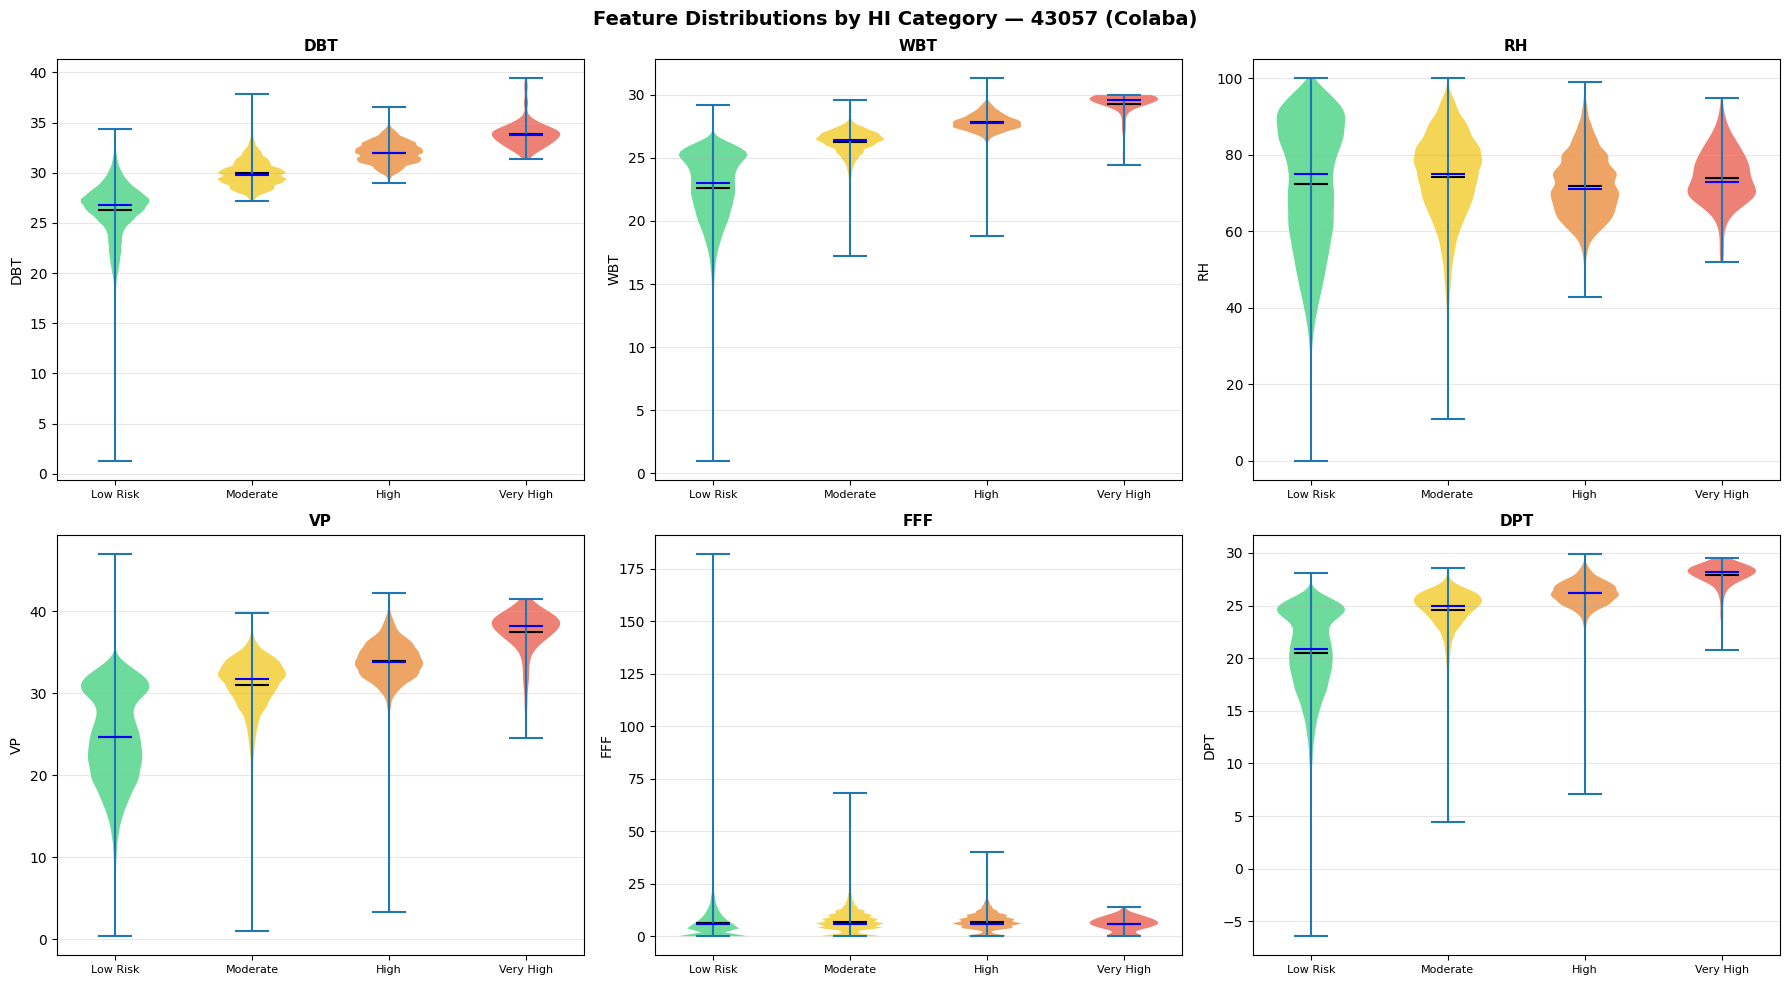

✅ Violin plots — HI


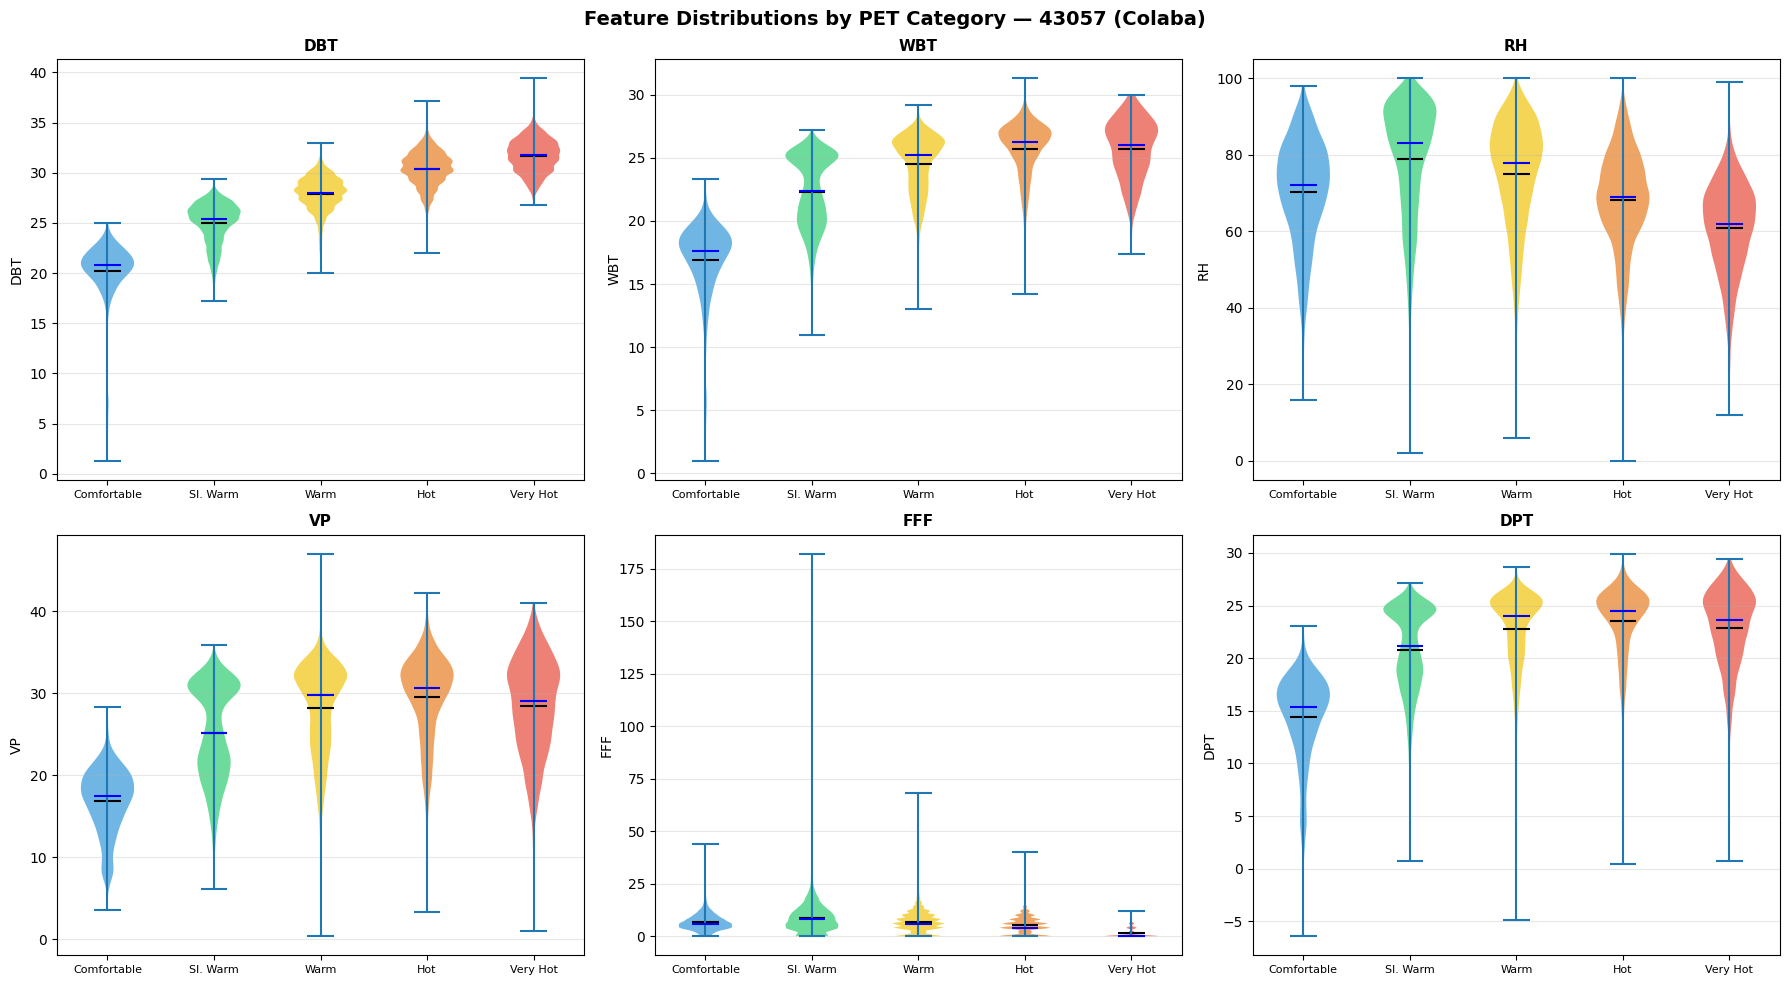

✅ Violin plots — PET


In [ ]:
# ============================================================
# VIZ 1: VIOLIN PLOTS — Feature distributions by class
# ============================================================
hi_names = {0:'Low Risk', 1:'Moderate', 2:'High', 3:'Very High'}
pet_names = {0:'Comfortable', 1:'Sl. Warm', 2:'Warm', 3:'Hot', 4:'Very Hot'}
hi_colors = ['#2ecc71','#f1c40f','#e67e22','#e74c3c']
pet_colors = ['#3498db','#2ecc71','#f1c40f','#e67e22','#e74c3c']

for target, names, colors, label in [('HI_Category', hi_names, hi_colors, 'HI'),
                                      ('PET_Category', pet_names, pet_colors, 'PET')]:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for i, col in enumerate(['DBT', 'WBT', 'RH', 'VP', 'FFF', 'DPT']):
        ax = axes[i//3][i%3]
        cats = sorted(df_clean[target].unique())
        data_list = [df_clean.loc[df_clean[target]==c, col].values for c in cats]

        parts = ax.violinplot(data_list, positions=range(len(cats)),
                               showmeans=True, showmedians=True)
        for j, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[j]); pc.set_alpha(0.7)
        parts['cmeans'].set_color('black')
        parts['cmedians'].set_color('blue')

        ax.set_xticks(range(len(cats)))
        ax.set_xticklabels([names[c] for c in cats], fontsize=8)
        ax.set_title(f'{col}', fontsize=11, fontweight='bold')
        ax.set_ylabel(col); ax.grid(axis='y', alpha=0.3)

    fig.suptitle(f'Feature Distributions by {label} Category — {STATION_LABEL}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{STATION_ID}_violin_{label}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Violin plots — {label}")


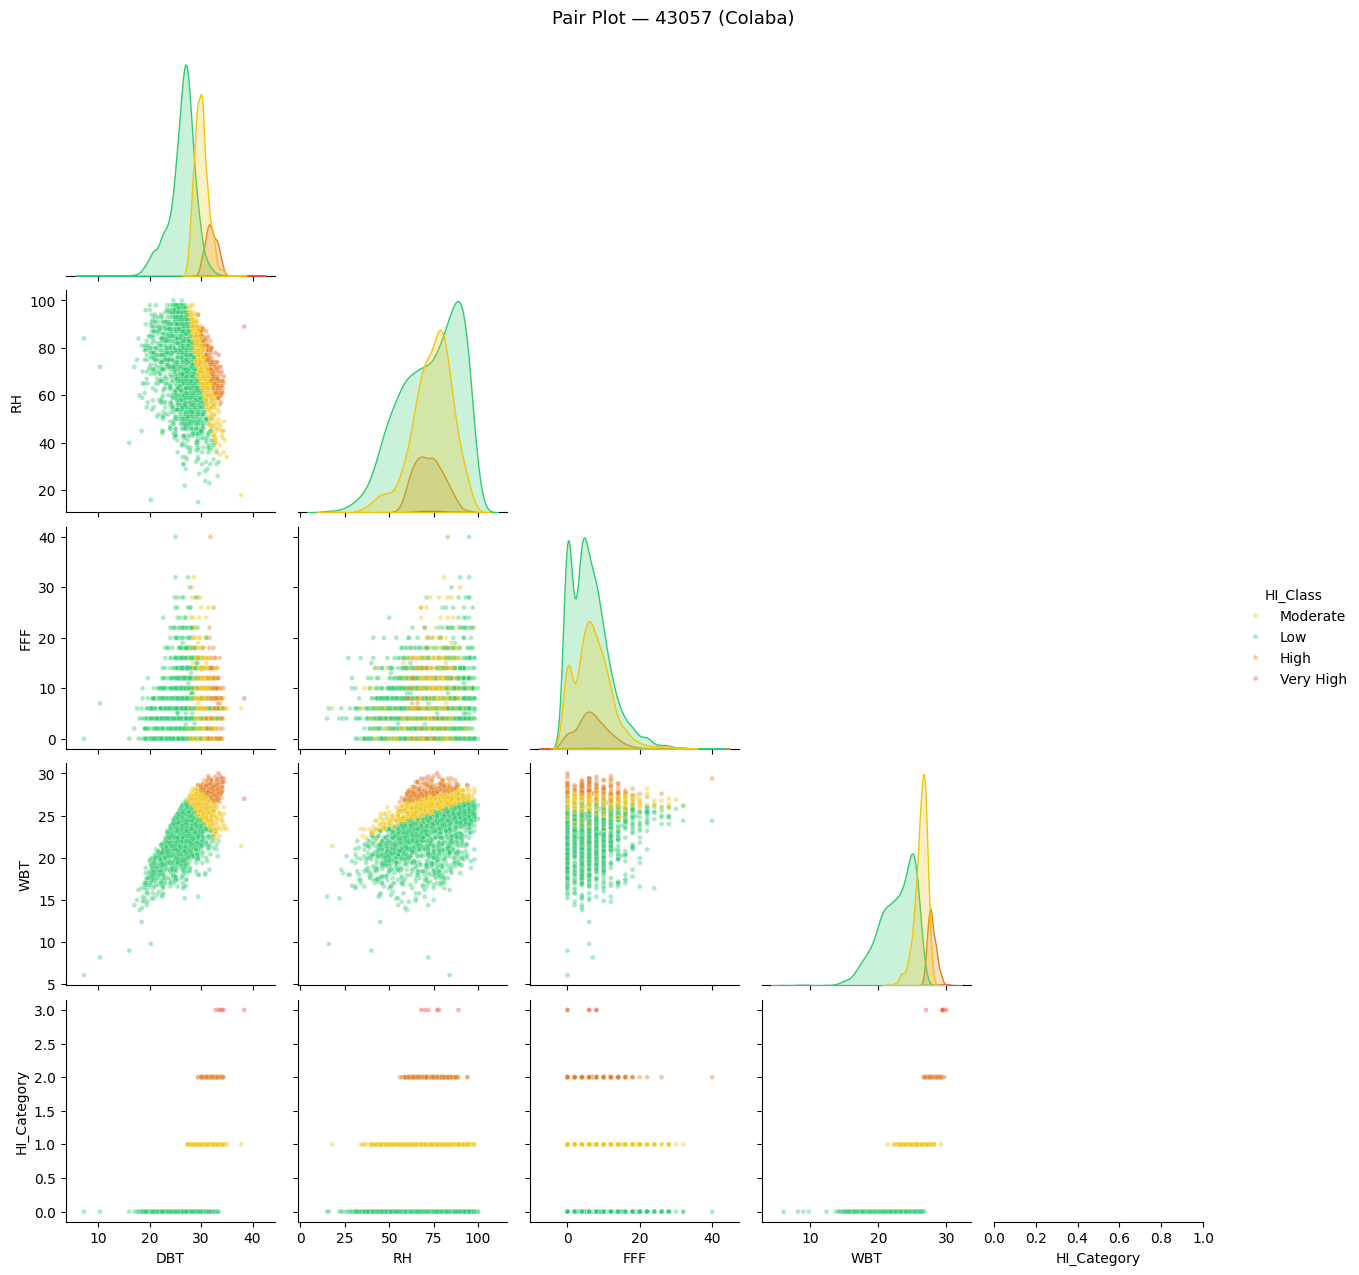

✅ Pair plot


In [ ]:
# ============================================================
# VIZ 2: PAIR PLOT with KDE — Key features by HI class
# ============================================================
np.random.seed(42)
sample_idx = np.random.choice(len(df_clean), size=min(3000, len(df_clean)), replace=False)
sample = df_clean.iloc[sample_idx][['DBT','RH','FFF','WBT','HI_Category']].copy()
sample['HI_Class'] = sample['HI_Category'].map(
    {0:'Low',1:'Moderate',2:'High',3:'Very High'})

g = sns.pairplot(sample, hue='HI_Class',
                 palette={'Low':'#2ecc71','Moderate':'#f1c40f',
                          'High':'#e67e22','Very High':'#e74c3c'},
                 diag_kind='kde', plot_kws={'alpha':0.4, 's':12}, corner=True)
g.figure.suptitle(f'Pair Plot — {STATION_LABEL}', y=1.02, fontsize=13)
plt.savefig(os.path.join(OUTPUT_DIR, f'{STATION_ID}_pairplot.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print("✅ Pair plot")


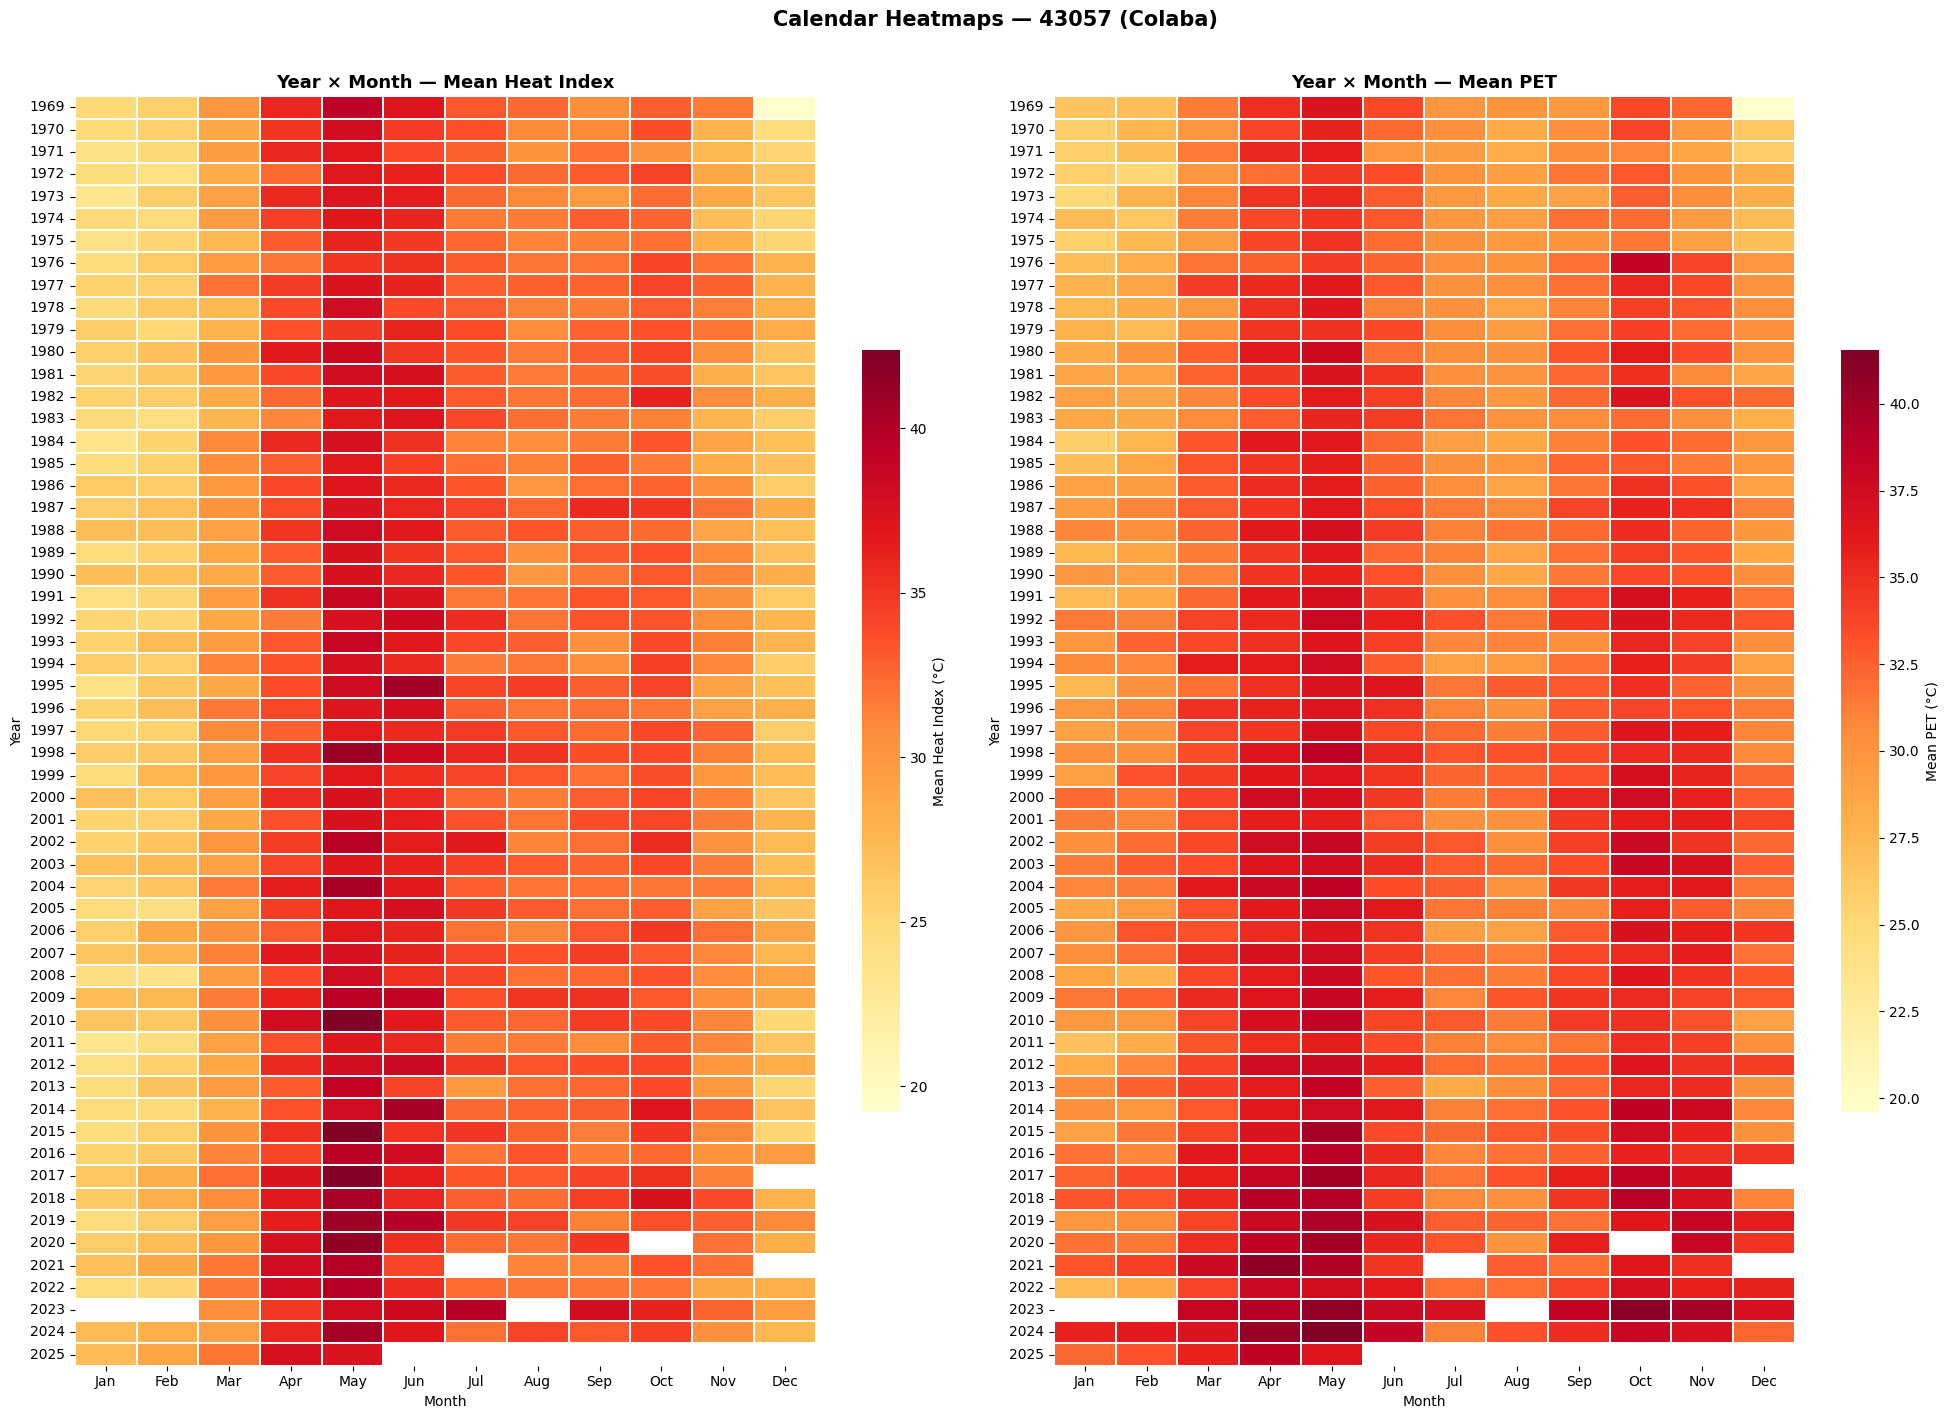

✅ Calendar heatmaps


In [ ]:
# ============================================================
# VIZ 3: CALENDAR HEATMAPS — Year × Month HI and PET
# ============================================================
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(20, 14))
for ax, var, label in [(axes[0],'HI','Heat Index'), (axes[1],'PET','PET')]:
    pivot = df.groupby(['YEAR','MN'])[var].mean().reset_index()
    pivot_mat = pivot.pivot(index='YEAR', columns='MN', values=var)
    sns.heatmap(pivot_mat, cmap='YlOrRd', ax=ax, linewidths=0.3,
                xticklabels=month_labels,
                cbar_kws={'label': f'Mean {label} (°C)', 'shrink': 0.6})
    ax.set_title(f'Year × Month — Mean {label}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Year'); ax.set_xlabel('Month')

fig.suptitle(f'Calendar Heatmaps — {STATION_LABEL}', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{STATION_ID}_calendar_heatmaps.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Calendar heatmaps")


Running t-SNE (1-2 min on 5000 samples)...


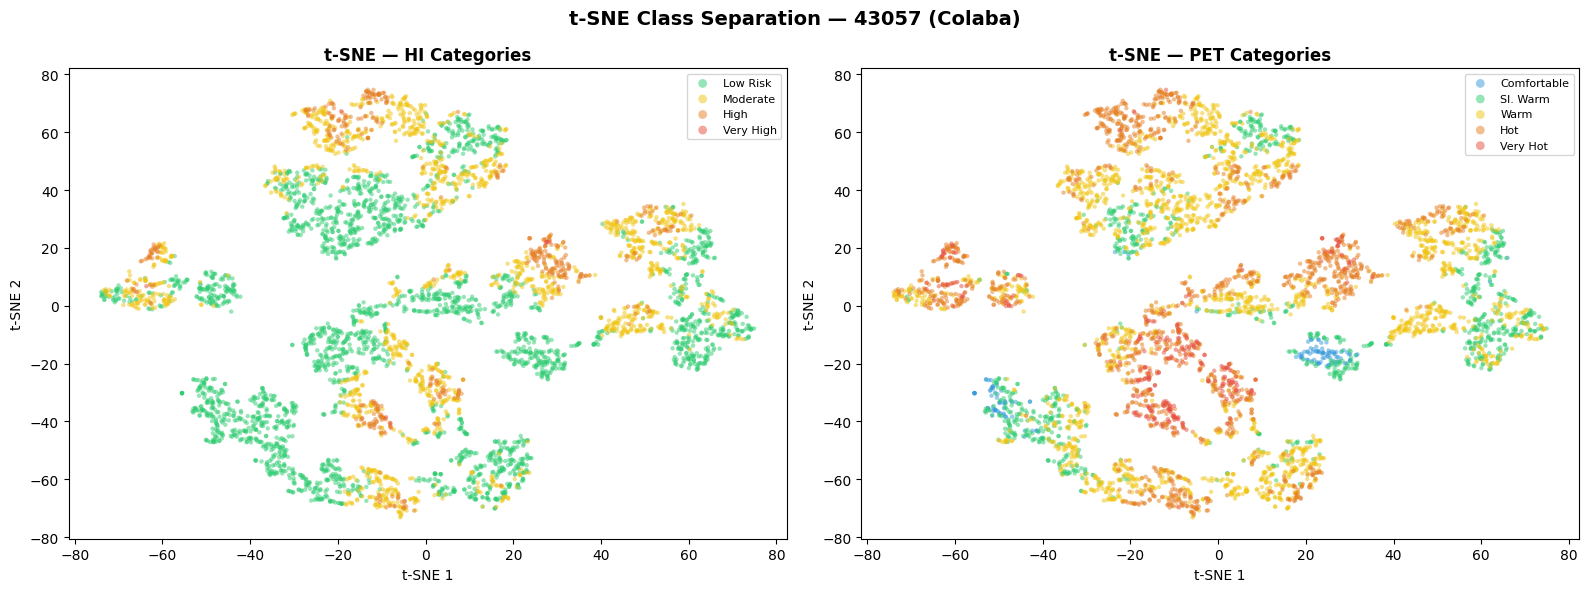

✅ t-SNE


In [ ]:
# ============================================================
# VIZ 4: t-SNE — Class separability in feature space
# ============================================================
print("Running t-SNE (1-2 min on 5000 samples)...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

np.random.seed(42)
tsne_n = 5000
tsne_idx = np.random.choice(len(X_scaled), size=min(tsne_n, len(X_scaled)), replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30,
            n_iter=1000, learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled[tsne_idx])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, y_arr, names, colors, label in [
    (axes[0], y_hi, hi_names, hi_colors, 'HI'),
    (axes[1], y_pet, pet_names, pet_colors, 'PET')]:
    for i, cat in enumerate(sorted(names.keys())):
        mask = y_arr[tsne_idx] == cat
        ax.scatter(X_tsne[mask,0], X_tsne[mask,1], c=colors[i],
                   label=names[cat], alpha=0.5, s=10, edgecolors='none')
    ax.set_title(f't-SNE — {label} Categories', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, markerscale=2)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')

fig.suptitle(f't-SNE Class Separation — {STATION_LABEL}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{STATION_ID}_tsne.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ t-SNE")


  SHAP ANALYSIS

  --- SHAP for HI ---
    Computed in 66.0s
    SHAP format: array (2000, 16, 4)
    Classes detected: 4


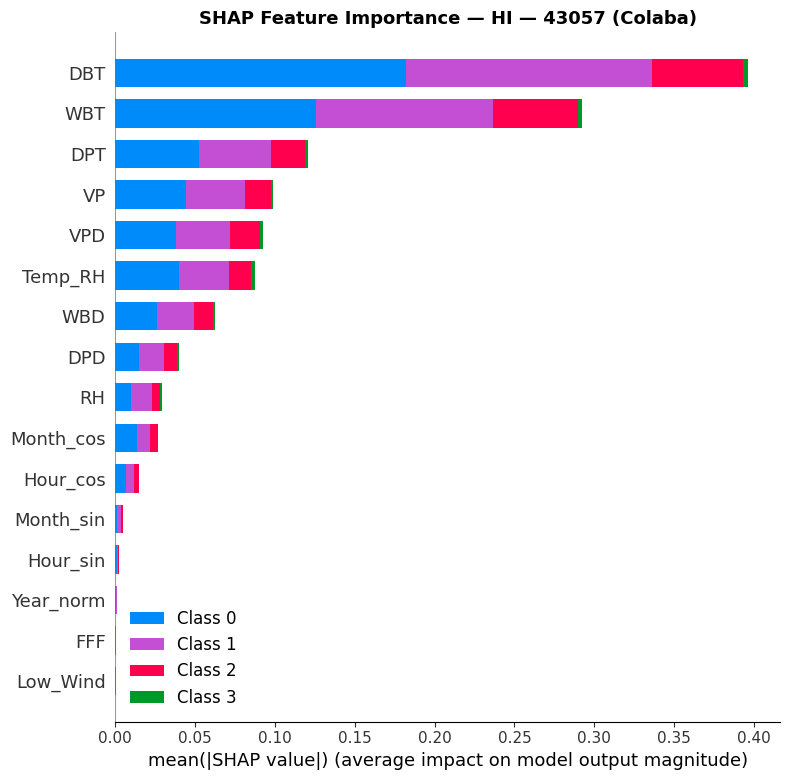

    ✅ SHAP bar plot


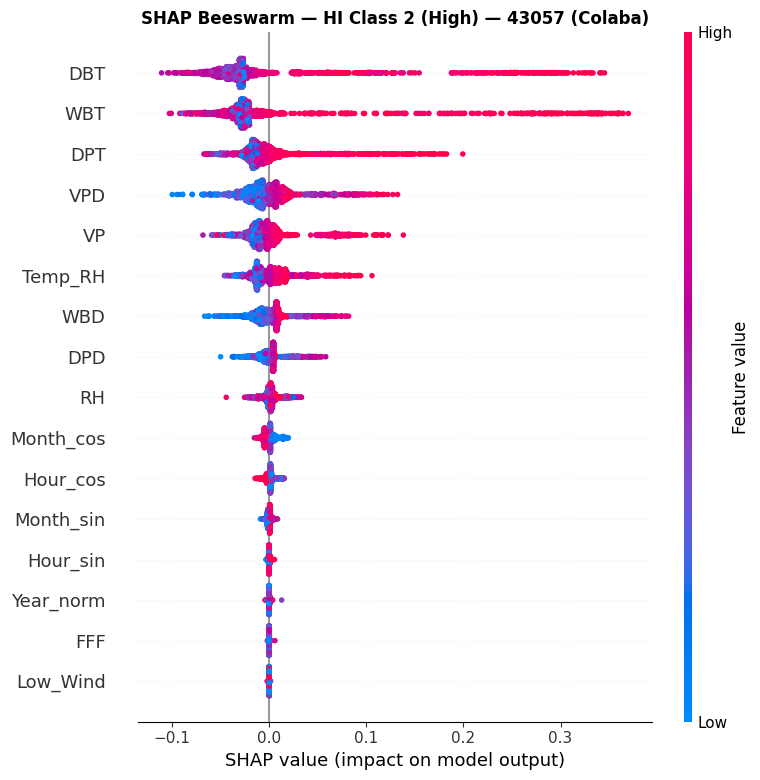

    ✅ SHAP beeswarm (class 2)


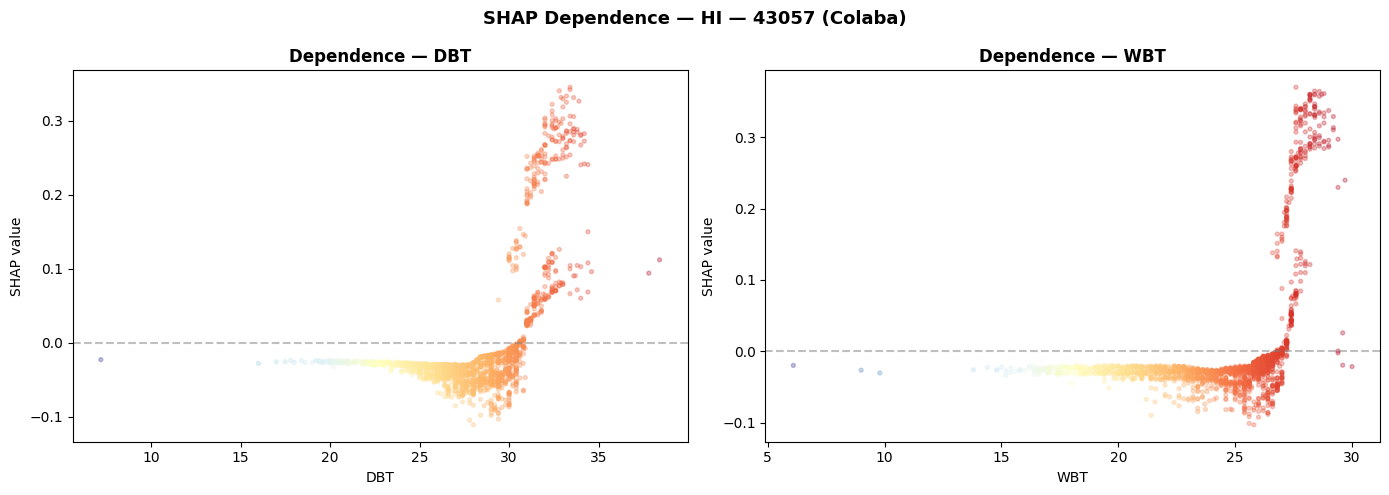

    ✅ SHAP dependence plots

  --- SHAP for PET ---
    Computed in 485.7s
    SHAP format: array (2000, 16, 5)
    Classes detected: 5


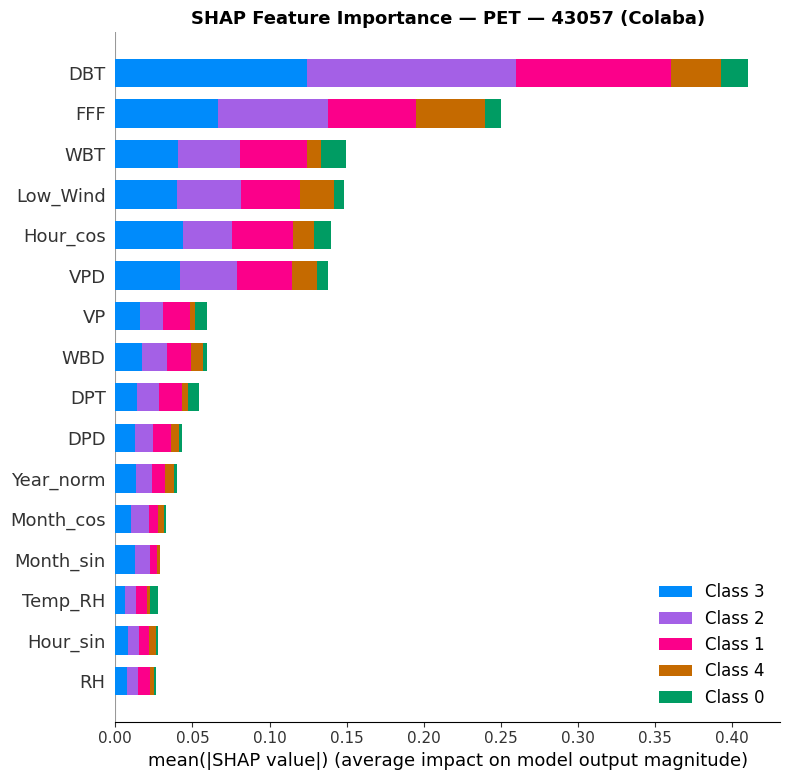

    ✅ SHAP bar plot


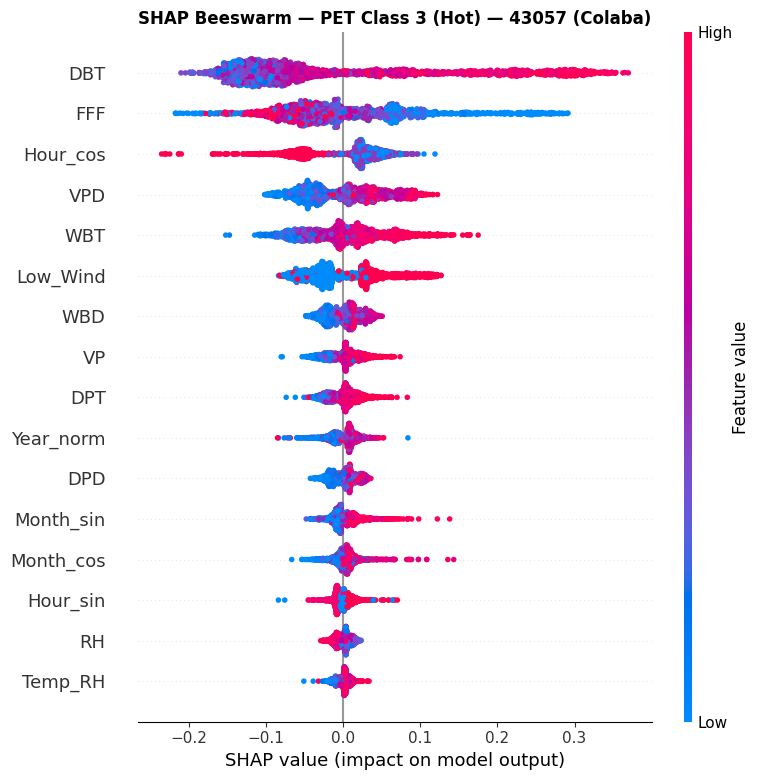

    ✅ SHAP beeswarm (class 3)


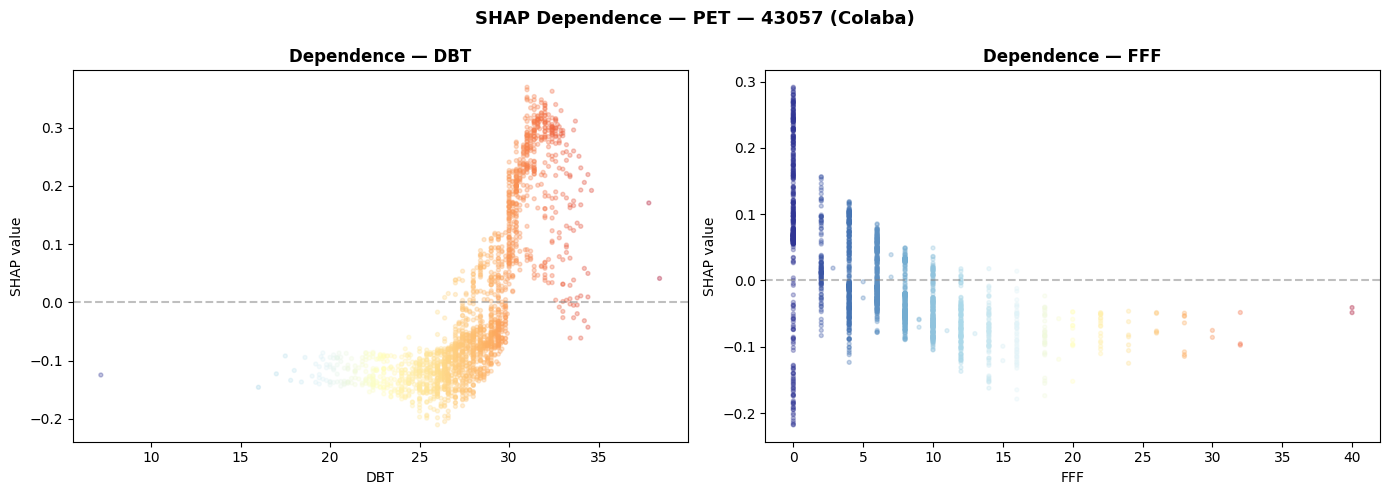

    ✅ SHAP dependence plots

✅ SHAP analysis complete!


In [ ]:
# ============================================================
# VIZ 5: SHAP ANALYSIS — FIXED VERSION
# ============================================================
print("="*70)
print("  SHAP ANALYSIS")
print("="*70)

shap_n = 2000
np.random.seed(42)
shap_idx = np.random.choice(len(X_df), size=min(shap_n, len(X_df)), replace=False)
X_shap = X_df.iloc[shap_idx].copy().reset_index(drop=True)

for target_name, y_full in [('HI', y_hi), ('PET', y_pet)]:
    print(f"\n  --- SHAP for {target_name} ---")

    # Train RF
    rf = RandomForestClassifier(n_estimators=200, random_state=42,
                                 n_jobs=-1, max_depth=12)
    rf.fit(X, y_full)

    # SHAP values
    t0 = time.time()
    explainer = shap.TreeExplainer(rf)
    shap_values_raw = explainer.shap_values(X_shap)
    print(f"    Computed in {time.time()-t0:.1f}s")

    # ── Handle both old (list) and new (3D array) SHAP formats ──
    if isinstance(shap_values_raw, list):
        # Old format: list of arrays, each (n_samples, n_features)
        shap_values_list = shap_values_raw
        shap_abs_mean = np.mean([np.abs(sv) for sv in shap_values_list], axis=0)
    elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
        # New format: (n_samples, n_features, n_classes)
        n_cls = shap_values_raw.shape[2]
        shap_values_list = [shap_values_raw[:, :, c] for c in range(n_cls)]
        shap_abs_mean = np.mean(np.abs(shap_values_raw), axis=(0, 2))
    else:
        # 2D array (binary or single output)
        shap_values_list = [shap_values_raw]
        shap_abs_mean = np.mean(np.abs(shap_values_raw), axis=0)

    print(f"    SHAP format: {'list' if isinstance(shap_values_raw, list) else f'array {shap_values_raw.shape}'}")
    print(f"    Classes detected: {len(shap_values_list)}")

    # --- Bar plot (global importance) ---
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_raw, X_shap, feature_names=ALL_FEATURES,
                      plot_type='bar', show=False, max_display=16)
    plt.title(f'SHAP Feature Importance — {target_name} — {STATION_LABEL}',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{STATION_ID}_shap_bar_{target_name}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"    ✅ SHAP bar plot")

    # --- Beeswarm for key class ---
    focus_class = 2 if target_name == 'HI' else 3
    focus_class = min(focus_class, len(shap_values_list) - 1)
    class_names = hi_names if target_name == 'HI' else pet_names

    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_list[focus_class], X_shap,
                      feature_names=ALL_FEATURES, show=False, max_display=16)
    plt.title(f'SHAP Beeswarm — {target_name} Class {focus_class} '
              f'({class_names[focus_class]}) — {STATION_LABEL}',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,
        f'{STATION_ID}_shap_beeswarm_{target_name}_class{focus_class}.png'),
        dpi=150, bbox_inches='tight')
    plt.show()
    print(f"    ✅ SHAP beeswarm (class {focus_class})")

    # --- Dependence plots for top 2 features ---
    # Get SHAP values for the focus class as a 2D array (samples × features)
    sv_focus = shap_values_list[focus_class]  # shape: (n_samples, n_features)
    mean_abs_per_feat = np.mean(np.abs(sv_focus), axis=0)
    top2 = np.argsort(mean_abs_per_feat)[-2:][::-1]

    fig, axes_d = plt.subplots(1, 2, figsize=(14, 5))
    for ax_i, feat_idx in enumerate(top2):
        feat_name = ALL_FEATURES[feat_idx]

        x_vals = X_shap.iloc[:, feat_idx].values   # (n_samples,)
        sv_vals = sv_focus[:, feat_idx]              # (n_samples,)

        # Safety check
        assert len(x_vals) == len(sv_vals), \
            f"Mismatch: x={len(x_vals)}, shap={len(sv_vals)}"

        axes_d[ax_i].scatter(x_vals, sv_vals, alpha=0.3, s=8,
                              c=x_vals, cmap='RdYlBu_r')
        axes_d[ax_i].set_xlabel(feat_name)
        axes_d[ax_i].set_ylabel(f'SHAP value')
        axes_d[ax_i].set_title(f'Dependence — {feat_name}', fontweight='bold')
        axes_d[ax_i].axhline(y=0, color='grey', linestyle='--', alpha=0.5)

    fig.suptitle(f'SHAP Dependence — {target_name} — {STATION_LABEL}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,
        f'{STATION_ID}_shap_dependence_{target_name}.png'),
        dpi=150, bbox_inches='tight')
    plt.show()
    print(f"    ✅ SHAP dependence plots")

print("\n✅ SHAP analysis complete!")


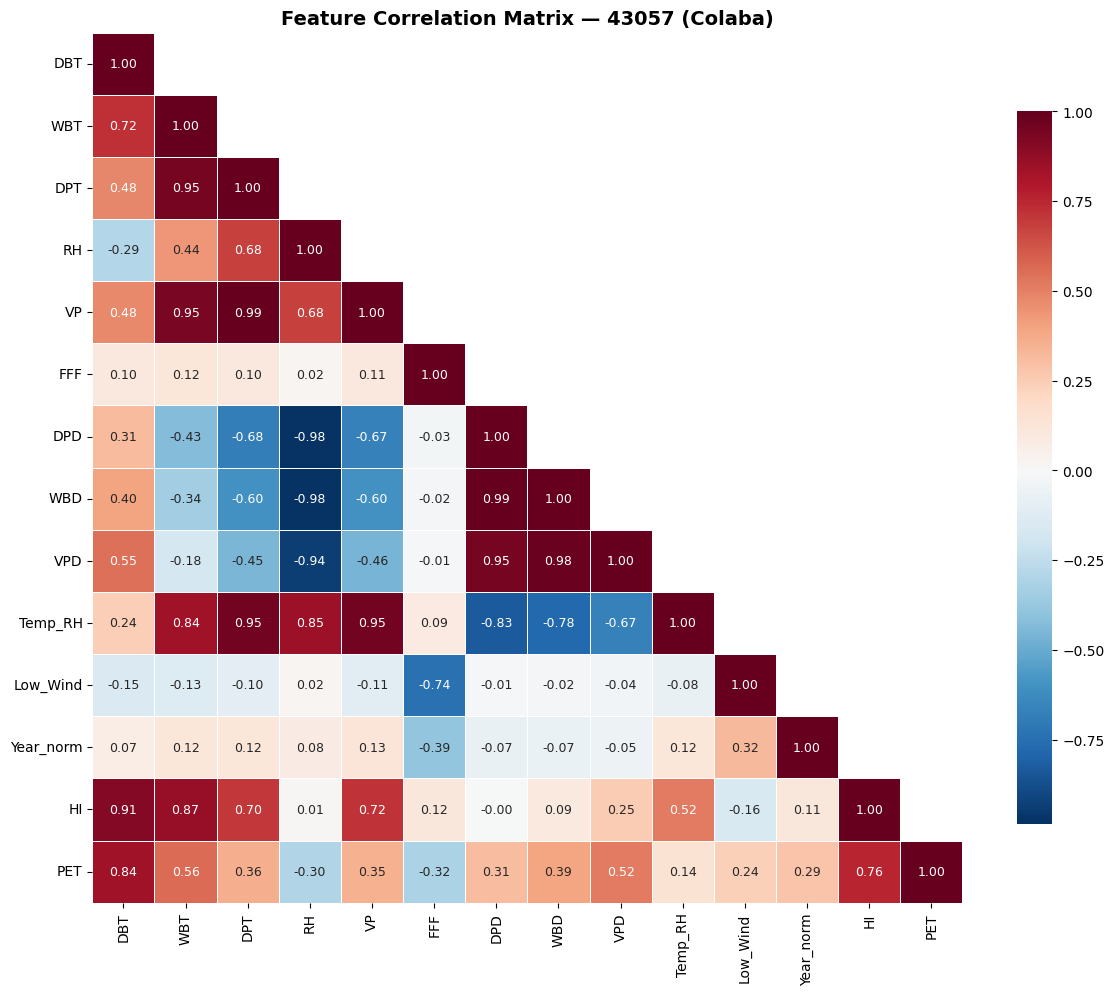

✅ Correlation heatmap


In [ ]:
# ============================================================
# VIZ 6: CORRELATION HEATMAP
# ============================================================
corr_cols = RAW_MET + DERIVED
corr_data = df_clean[corr_cols].copy()
corr_data['HI'] = df.loc[df_clean.index, 'HI'].values
corr_data['PET'] = df.loc[df_clean.index, 'PET'].values

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = corr_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, ax=ax, linewidths=0.5,
            cbar_kws={'shrink':0.8}, annot_kws={'size':9})
ax.set_title(f'Feature Correlation Matrix — {STATION_LABEL}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{STATION_ID}_correlation.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation heatmap")


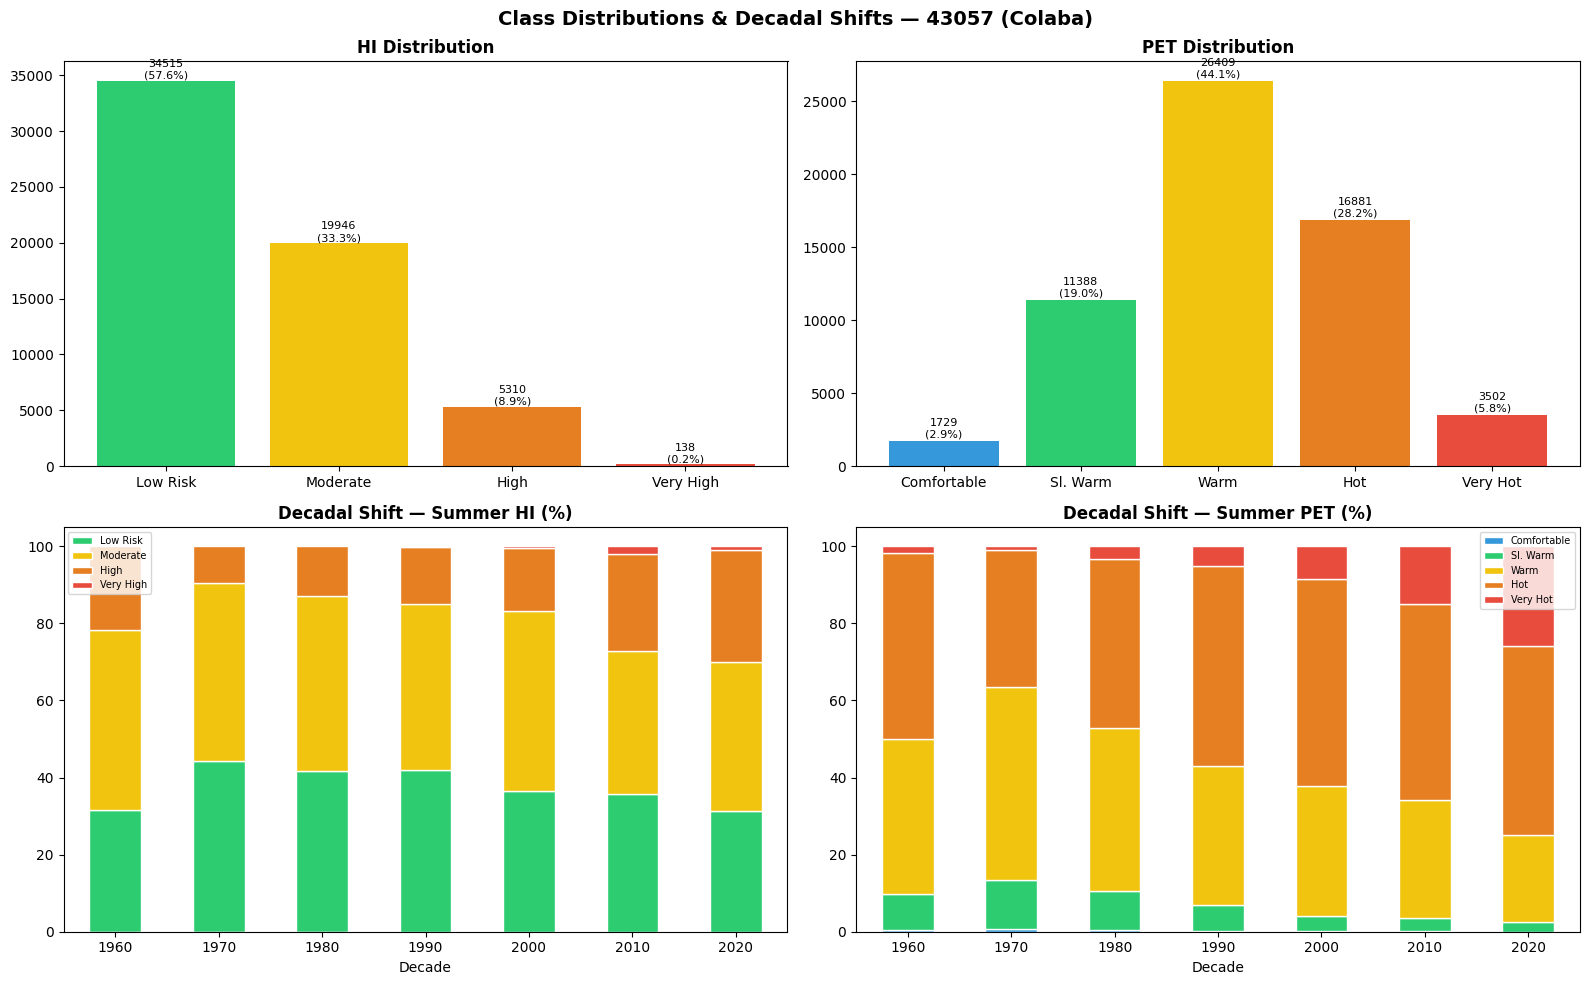

✅ Distributions + decadal shifts


In [ ]:
# ============================================================
# VIZ 7: CLASS DISTRIBUTIONS + DECADAL SHIFT
# ============================================================
df_clean['Decade'] = (df_clean['YEAR'] // 10) * 10

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# HI distribution
hi_counts = df_clean['HI_Category'].value_counts().sort_index()
axes[0][0].bar([hi_names[i] for i in hi_counts.index], hi_counts.values, color=hi_colors)
axes[0][0].set_title(f'HI Distribution', fontweight='bold')
for i, v in enumerate(hi_counts.values):
    axes[0][0].text(i, v+200, f'{v}\n({v/len(df_clean)*100:.1f}%)', ha='center', fontsize=8)

# PET distribution
pet_counts = df_clean['PET_Category'].value_counts().sort_index()
axes[0][1].bar([pet_names[i] for i in pet_counts.index], pet_counts.values, color=pet_colors)
axes[0][1].set_title(f'PET Distribution', fontweight='bold')
for i, v in enumerate(pet_counts.values):
    axes[0][1].text(i, v+200, f'{v}\n({v/len(df_clean)*100:.1f}%)', ha='center', fontsize=8)

# Decadal HI shift (summer)
summer = df_clean[df_clean['MN'].isin([3,4,5])]
dec_hi = summer.groupby(['Decade','HI_Category']).size().unstack(fill_value=0)
(dec_hi.div(dec_hi.sum(axis=1), axis=0)*100).plot(
    kind='bar', stacked=True, ax=axes[1][0], color=hi_colors, edgecolor='white')
axes[1][0].set_title('Decadal Shift — Summer HI (%)', fontweight='bold')
axes[1][0].legend([hi_names[i] for i in range(4)], fontsize=7)
axes[1][0].set_xticklabels(axes[1][0].get_xticklabels(), rotation=0)

# Decadal PET shift (summer)
dec_pet = summer.groupby(['Decade','PET_Category']).size().unstack(fill_value=0)
(dec_pet.div(dec_pet.sum(axis=1), axis=0)*100).plot(
    kind='bar', stacked=True, ax=axes[1][1], color=pet_colors, edgecolor='white')
axes[1][1].set_title('Decadal Shift — Summer PET (%)', fontweight='bold')
axes[1][1].legend([pet_names[i] for i in range(min(5,len(dec_pet.columns)))], fontsize=7)
axes[1][1].set_xticklabels(axes[1][1].get_xticklabels(), rotation=0)

fig.suptitle(f'Class Distributions & Decadal Shifts — {STATION_LABEL}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{STATION_ID}_distributions_decadal.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Distributions + decadal shifts")


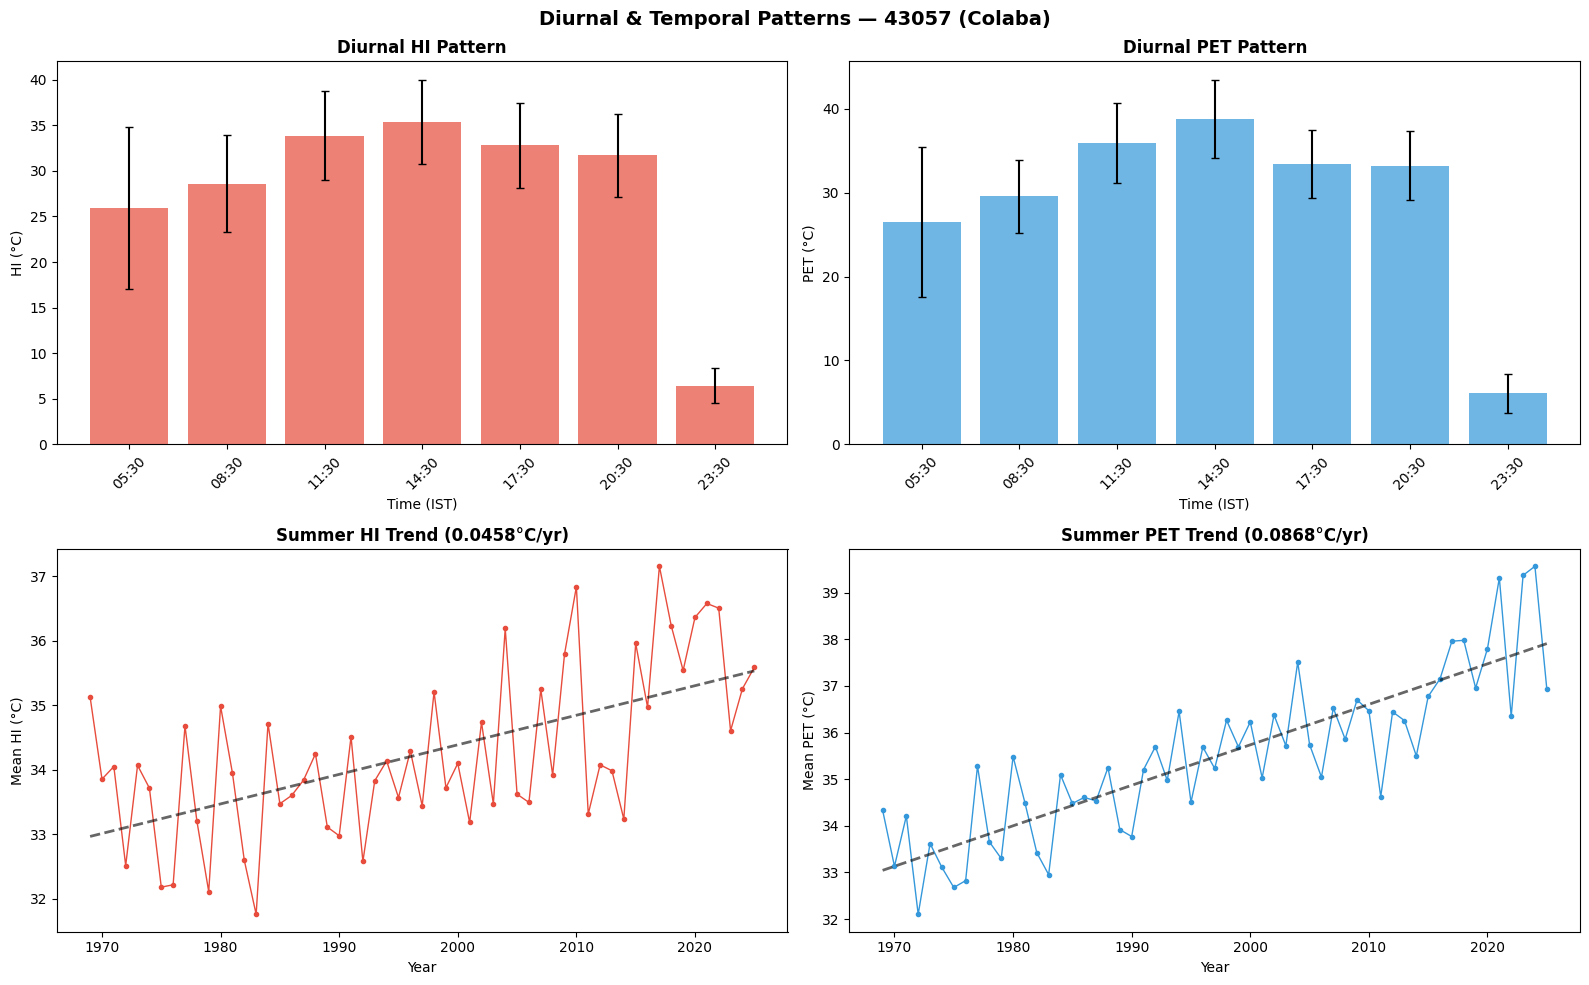

✅ Diurnal + temporal trends


In [ ]:
# ============================================================
# VIZ 8: DIURNAL + TEMPORAL TRENDS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
hr_map = {0:'05:30',12:'08:30',24:'11:30',36:'14:30',
          48:'17:30',60:'20:30',72:'23:30',84:'02:30'}

# Diurnal HI and PET
for ax, var, color in [(axes[0][0],'HI','#e74c3c'), (axes[0][1],'PET','#3498db')]:
    hourly = df.groupby('HR')[var].agg(['mean','std'])
    hr_labels = [hr_map.get(h,str(h)) for h in hourly.index]
    ax.bar(range(len(hourly)), hourly['mean'], yerr=hourly['std'],
           color=color, alpha=0.7, capsize=3)
    ax.set_xticks(range(len(hourly)))
    ax.set_xticklabels(hr_labels, rotation=45)
    ax.set_title(f'Diurnal {var} Pattern', fontweight='bold')
    ax.set_xlabel('Time (IST)'); ax.set_ylabel(f'{var} (°C)')

# Temporal trends (summer)
summer_full = df[df['MN'].isin([3,4,5])]
for ax, var, color in [(axes[1][0],'HI','#e74c3c'), (axes[1][1],'PET','#3498db')]:
    annual = summer_full.groupby('YEAR')[var].mean()
    ax.plot(annual.index, annual.values, 'o-', color=color, markersize=3, linewidth=1)
    z = np.polyfit(annual.index, annual.values, 1)
    ax.plot(annual.index, np.polyval(z, annual.index), '--', color='black',
            linewidth=2, alpha=0.6)
    ax.set_title(f'Summer {var} Trend ({z[0]:.4f}°C/yr)', fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel(f'Mean {var} (°C)')

fig.suptitle(f'Diurnal & Temporal Patterns — {STATION_LABEL}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{STATION_ID}_diurnal_temporal.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Diurnal + temporal trends")


## 3. Feature Selection (6 Methods Including SHAP)

In [ ]:
# ============================================================
# FEATURE SELECTION — 6 methods for HI and PET
# ============================================================
print("="*70)
print("  FEATURE SELECTION (6 Methods)")
print("="*70)

results_all = {}

for target_name, y in [('HI', y_hi), ('PET', y_pet)]:
    print(f"\n  --- {target_name} ---")
    results = {}

    # 1. Pearson Correlation
    results['Pearson'] = np.array([abs(np.corrcoef(X[:,i], y)[0,1])
                                    for i in range(X.shape[1])])
    print("  ✅ Pearson Correlation")

    # 2. Mutual Information
    results['MI'] = mutual_info_classif(X, y, random_state=42, n_neighbors=5)
    print("  ✅ Mutual Information")

    # 3. ANOVA F-statistic
    results['ANOVA'], _ = f_classif(X, y)
    print("  ✅ ANOVA F-statistic")

    # 4. Random Forest
    rf = RandomForestClassifier(n_estimators=200, random_state=42,
                                 n_jobs=-1, max_depth=12)
    rf.fit(X, y)
    results['RF'] = rf.feature_importances_
    print("  ✅ Random Forest Importance")

    # 5. Gradient Boosting
    gb = GradientBoostingClassifier(n_estimators=150, random_state=42,
                                     max_depth=5, subsample=0.8)
    gb.fit(X, y)
    results['GB'] = gb.feature_importances_
    print("  ✅ Gradient Boosting Importance")

    # 6. SHAP (mean |SHAP|)
    explainer = shap.TreeExplainer(rf)
    shap_sample = X_df.iloc[np.random.RandomState(42).choice(
        len(X_df), size=min(2000, len(X_df)), replace=False)]
    sv = explainer.shap_values(shap_sample)
    # Handle all SHAP output formats → always get 1D array (n_features,)
    if isinstance(sv, list):
        # Old format: list of (n_samples, n_features) per class
        results['SHAP'] = np.mean([np.mean(np.abs(s), axis=0) for s in sv], axis=0)
    elif isinstance(sv, np.ndarray):
        if sv.ndim == 3:
            # New format: (n_samples, n_features, n_classes) → mean over samples AND classes
            results['SHAP'] = np.mean(np.abs(sv), axis=0).mean(axis=1)
        elif sv.ndim == 2:
            # Binary: (n_samples, n_features)
            results['SHAP'] = np.mean(np.abs(sv), axis=0)
        else:
            results['SHAP'] = np.abs(sv)
    print(f"    SHAP shape: {results['SHAP'].shape}")  # Should print (16,)
    print("  ✅ SHAP Importance")

    results_all[target_name] = results

# Rank aggregation function
def rank_features(results, feature_names):
    score_df = pd.DataFrame()
    for method, scores in results.items():
        score_df[method] = scores / (scores.max() + 1e-10)
    score_df.index = feature_names
    score_df['Avg_Score'] = score_df.mean(axis=1)
    return score_df.sort_values('Avg_Score', ascending=False)

# Print rankings
for target_name in ['HI', 'PET']:
    score_df = rank_features(results_all[target_name], ALL_FEATURES)
    print(f"\n{'='*70}")
    print(f"  {target_name} Feature Rankings (6 methods)")
    print(f"{'='*70}")
    print(score_df.round(3).to_string())


  FEATURE SELECTION (6 Methods)

  --- HI ---
  ✅ Pearson Correlation
  ✅ Mutual Information
  ✅ ANOVA F-statistic
  ✅ Random Forest Importance
  ✅ Gradient Boosting Importance
    SHAP shape: (16,)
  ✅ SHAP Importance

  --- PET ---
  ✅ Pearson Correlation
  ✅ Mutual Information
  ✅ ANOVA F-statistic
  ✅ Random Forest Importance
  ✅ Gradient Boosting Importance
    SHAP shape: (16,)
  ✅ SHAP Importance

  HI Feature Rankings (6 methods)
           Pearson     MI  ANOVA     RF     GB   SHAP  Avg_Score
WBT          0.975  0.737  0.944  0.948  1.000  0.737      0.890
DBT          1.000  0.646  1.000  1.000  0.665  1.000      0.885
VP           0.864  0.403  0.622  0.321  0.003  0.249      0.410
DPT          0.808  0.407  0.520  0.320  0.005  0.304      0.394
Temp_RH      0.595  0.910  0.239  0.156  0.048  0.221      0.362
VPD          0.265  1.000  0.038  0.214  0.005  0.234      0.293
Month_cos    0.726  0.216  0.373  0.069  0.000  0.068      0.242
Hour_cos     0.328  0.074  0.062  0.02

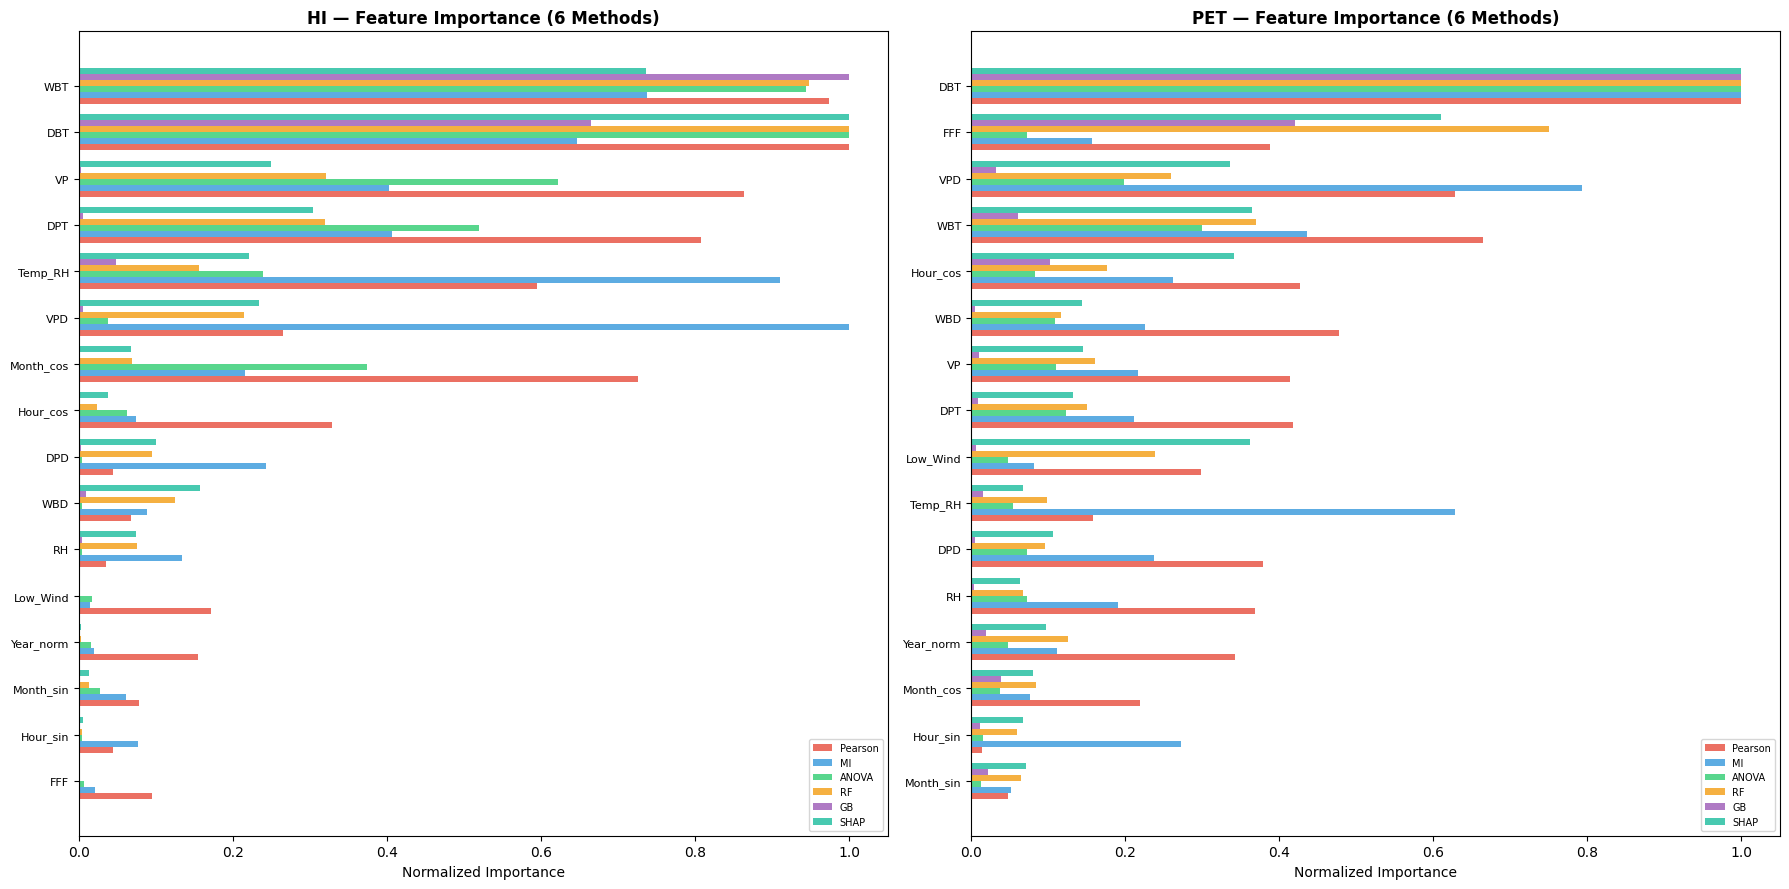

✅ Feature importance comparison (6 methods)


In [ ]:
# ============================================================
# FEATURE IMPORTANCE VISUALIZATION (6 methods)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, target_name in [(axes[0], 'HI'), (axes[1], 'PET')]:
    score_df = rank_features(results_all[target_name], ALL_FEATURES)
    score_sorted = score_df.sort_values('Avg_Score', ascending=True)

    methods = ['Pearson','MI','ANOVA','RF','GB','SHAP']
    colors_m = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']
    y_pos = np.arange(len(ALL_FEATURES))
    h = 0.13

    for j, (method, color) in enumerate(zip(methods, colors_m)):
        ax.barh(y_pos + j*h, score_sorted[method].values, h,
                label=method, color=color, alpha=0.8)

    ax.set_yticks(y_pos + 2.5*h)
    ax.set_yticklabels(score_sorted.index, fontsize=8)
    ax.set_xlabel('Normalized Importance')
    ax.set_title(f'{target_name} — Feature Importance (6 Methods)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{STATION_ID}_feature_importance_6methods.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance comparison (6 methods)")


In [ ]:
# ============================================================
# FINAL FEATURE SELECTION — Top features by combined score
# ============================================================
hi_scores = rank_features(results_all['HI'], ALL_FEATURES)
pet_scores = rank_features(results_all['PET'], ALL_FEATURES)
combined = (hi_scores['Avg_Score'] + pet_scores['Avg_Score']) / 2

print("="*70)
print("  COMBINED RANKING (HI + PET averaged)")
print("="*70)
combined_sorted = combined.sort_values(ascending=False)
for i, (feat, score) in enumerate(combined_sorted.items(), 1):
    hi_r = hi_scores['Avg_Score'].rank(ascending=False)[feat]
    pet_r = pet_scores['Avg_Score'].rank(ascending=False)[feat]
    marker = "  ← SELECTED" if i <= 10 else ""
    print(f"  {i:2d}. {feat:<18s}  Score: {score:.3f}  "
          f"(HI #{hi_r:.0f}, PET #{pet_r:.0f}){marker}")

SELECTED_FEATURES = combined_sorted.head(10).index.tolist()
print(f"\n  ✅ FINAL {len(SELECTED_FEATURES)} FEATURES: {SELECTED_FEATURES}")

# Save feature list
with open(os.path.join(OUTPUT_DIR, f'{STATION_ID}_selected_features.txt'), 'w') as f:
    f.write(f"SELECTED FEATURES — Station {STATION_ID}\n{'='*50}\n\n")
    for i, feat in enumerate(SELECTED_FEATURES, 1):
        f.write(f"{i:2d}. {feat}\n")
    f.write(f"\nMethods: Pearson, MI, ANOVA-F, RF, GB, SHAP\n")
    f.write(f"Aggregation: Mean normalized score\n")
print(f"  ✅ Feature list saved")


  COMBINED RANKING (HI + PET averaged)
   1. DBT                 Score: 0.943  (HI #2, PET #1)  ← SELECTED
   2. WBT                 Score: 0.628  (HI #1, PET #4)  ← SELECTED
   3. VPD                 Score: 0.333  (HI #6, PET #3)  ← SELECTED
   4. VP                  Score: 0.293  (HI #3, PET #7)  ← SELECTED
   5. DPT                 Score: 0.284  (HI #4, PET #8)  ← SELECTED
   6. Temp_RH             Score: 0.266  (HI #5, PET #10)  ← SELECTED
   7. FFF                 Score: 0.210  (HI #16, PET #2)  ← SELECTED
   8. Month_cos           Score: 0.166  (HI #7, PET #14)  ← SELECTED
   9. Hour_cos            Score: 0.160  (HI #8, PET #5)  ← SELECTED
  10. WBD                 Score: 0.127  (HI #10, PET #6)  ← SELECTED
  11. DPD                 Score: 0.115  (HI #9, PET #11)
  12. Low_Wind            Score: 0.103  (HI #12, PET #9)
  13. RH                  Score: 0.091  (HI #11, PET #12)
  14. Year_norm           Score: 0.078  (HI #13, PET #13)
  15. Hour_sin            Score: 0.048  (HI #15